# Account Predictor - Model Training

This notebook trains machine learning models to predict account categories from transaction data.

## Approach:
- **Random Forest** - Best for tabular data with mixed features
- **Train/Validation/Test split** - 70/15/15 for robust evaluation
- **Data randomization** - Shuffle before splitting to avoid temporal bias
- **Feature engineering** - Extract meaningful patterns from dates, amounts, and descriptions


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print("Random seed set to 42 for reproducibility")


Libraries imported successfully!
Random seed set to 42 for reproducibility


## 1. Load and Prepare Data


In [72]:
# Load your transaction data
df = pd.read_csv('../data/data_template.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
print(df.head())

# Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())


Dataset shape: (3493, 6)
Columns: ['Date', 'Description', 'Account', ' Amount ', 'Unnamed: 4', 'Unnamed: 5']

First few rows:
        Date                   Description                  Account   Amount   \
0  21-Jul-23                         Jump+          Office Supplies   -91.98    
1  31-Jul-23              COSTCO WHOLESALE          Office Supplies  -400.99    
2  31-Jul-23              STARBUCKS COFFEE  Meals and Entertainment    -7.42    
3   1-Dec-23  PRE-AUTH PYMT - OTFS FEE BPY             Bank Charges   -40.00    
4   2-Jan-24  PRE-AUTH PYMT - OTFS FEE BPY             Bank Charges    -3.50    

   Unnamed: 4  Unnamed: 5  
0         NaN         NaN  
1         NaN         NaN  
2         NaN         NaN  
3         NaN         NaN  
4         NaN         NaN  

Missing values:
Date              1
Description       0
Account           0
 Amount           0
Unnamed: 4     3493
Unnamed: 5     3493
dtype: int64


In [73]:
# Clean the data
print("Cleaning data...")

# Remove any rows with missing critical data
df = df.dropna(subset=['Date', 'Description', 'Account'])

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Handle Excel errors in Date column
print("Checking for Excel errors in Date column...")
excel_errors = df['Date'].astype(str).str.contains('#VALUE!|#REF!|#NAME?', na=False)
if excel_errors.any():
    print(f"Found {excel_errors.sum()} rows with Excel errors in Date column")
    print("Removing these rows...")
    df = df[~excel_errors]

# Convert Date to datetime with error handling
print("Converting dates...")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove rows where date conversion failed
date_na = df['Date'].isna()
if date_na.any():
    print(f"Removing {date_na.sum()} rows with invalid dates...")
    df = df[~date_na]

# Clean Amount column (remove commas and convert to float)
print("Cleaning amounts...")
df['Amount'] = df['Amount'].astype(str).str.replace(',', '').str.replace(' ', '')
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# Remove rows with invalid amounts
amount_na = df['Amount'].isna()
if amount_na.any():
    print(f"Removing {amount_na.sum()} rows with invalid amounts...")
    df = df[~amount_na]

# Remove zero amounts (not useful for prediction)
zero_amounts = df['Amount'] == 0
if zero_amounts.any():
    print(f"Removing {zero_amounts.sum()} rows with zero amounts...")
    df = df[~zero_amounts]

# Filter classes with sufficient samples for better model performance
print("Filtering classes with sufficient samples...")
class_counts = df['Account'].value_counts()
min_samples = 20  # Only keep classes with 20+ samples
valid_classes = class_counts[class_counts >= min_samples].index

print(f"Classes with >= {min_samples} samples: {len(valid_classes)}")
print(f"Removed classes: {len(class_counts) - len(valid_classes)}")

if len(class_counts) - len(valid_classes) > 0:
    print("Removed classes:")
    removed_classes = class_counts[class_counts < min_samples]
    for class_name, count in removed_classes.items():
        print(f"  - {class_name}: {count} samples")

# Filter data to only include valid classes
df = df[df['Account'].isin(valid_classes)].copy()

print(f"After cleaning and filtering: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Amount range: ${df['Amount'].min():.2f} to ${df['Amount'].max():.2f}")

# Show account distribution
print(f"\nFinal account categories ({df['Account'].nunique()} total):")
print(df['Account'].value_counts())


Cleaning data...
Checking for Excel errors in Date column...
Converting dates...
Cleaning amounts...
Filtering classes with sufficient samples...
Classes with >= 20 samples: 22
Removed classes: 32
Removed classes:
  - Income Tax Refund: 18 samples
  - Property Tax: 18 samples
  - Personal Expenses: 16 samples
  - Interest: 13 samples
  - Loan: 12 samples
  - Internet: 12 samples
  - Purchases: 10 samples
  - Dispatcher Expense: 9 samples
  - Children Education Investment: 8 samples
  - Repair and Maintenance: 8 samples
  - Accounting fees: 7 samples
  - Waste Management: 6 samples
  - Income Tax Payment: 6 samples
  - Sub-contract : 6 samples
  - Interest Income: 5 samples
  - Loan : 5 samples
  - Cleaning Expense: 4 samples
  - GST/HST Payable: 4 samples
  - Loan Interest: 3 samples
  - Repair and maintenance: 3 samples
  - Ask my Accountant: 2 samples
  - Intercompany: 2 samples
  - Postage & Courier: 2 samples
  - Professional Fees: 2 samples
  - Salary Expense - Nitin Gujare: 2 sam

## 2. Feature Engineering


In [74]:
# Create features from the data
print("Creating features...")

# Date features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['Quarter'] = df['Date'].dt.quarter

# Amount features
df['Amount_Abs'] = df['Amount'].abs()
df['IsIncome'] = (df['Amount'] > 0).astype(int)
df['Amount_Log'] = np.log1p(df['Amount_Abs'])  # log(1 + amount) to handle zeros

# Description features
df['Description_Length'] = df['Description'].str.len()
df['Word_Count'] = df['Description'].str.split().str.len()
df['Has_Numbers'] = df['Description'].str.contains(r'\d').astype(int)
df['Has_Special_Chars'] = df['Description'].str.contains(r'[!@#$%^&*(),.?":{}|<>]').astype(int)

# Clean descriptions for TF-IDF
def clean_text(text):
    """Clean transaction descriptions"""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = ' '.join(text.split())
    return text

df['Description_Clean'] = df['Description'].apply(clean_text)

# TF-IDF features for text analysis
print("Creating TF-IDF features...")
tfidf = TfidfVectorizer(
    max_features=300,  # Reduced for better performance
    min_df=5,          # Word must appear in at least 5 documents
    max_df=0.7,        # Word must appear in less than 70% of documents
    stop_words='english',
    ngram_range=(1, 2)  # Include both single words and 2-word phrases
)

tfidf_matrix = tfidf.fit_transform(df['Description_Clean'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f'tfidf_{word}' for word in tfidf.get_feature_names_out()],
    index=df.index
)

print(f"Created {tfidf_df.shape[1]} TF-IDF features")

# Combine basic features with TF-IDF features
basic_features = [
    'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Quarter',
    'Amount_Abs', 'IsIncome', 'Amount_Log',
    'Description_Length', 'Word_Count', 'Has_Numbers', 'Has_Special_Chars'
]

X_basic = df[basic_features].copy()
X_combined = pd.concat([X_basic, tfidf_df], axis=1)

print(f"Total features created: {X_combined.shape[1]}")
print(f"Basic features: {len(basic_features)}")
print(f"TF-IDF features: {tfidf_df.shape[1]}")


Creating features...
Creating TF-IDF features...


Created 300 TF-IDF features
Total features created: 313
Basic features: 13
TF-IDF features: 300


## 3. Text Feature Engineering with Vocabulary


In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler
import re

# Clean and preprocess text descriptions
def clean_text(text):
    """Clean transaction descriptions for better feature extraction"""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove special characters but keep spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply text cleaning
df['Description_Clean'] = df['Description'].apply(clean_text)

print("Sample cleaned descriptions:")
for i in range(5):
    print(f"Original: {df['Description'].iloc[i]}")
    print(f"Cleaned:  {df['Description_Clean'].iloc[i]}")
    print()


Sample cleaned descriptions:
Original: Jump+
Cleaned:  jump

Original: COSTCO WHOLESALE
Cleaned:  costco wholesale

Original: STARBUCKS COFFEE
Cleaned:  starbucks coffee

Original: PRE-AUTH PYMT - OTFS FEE BPY
Cleaned:  pre auth pymt otfs fee bpy

Original: PRE-AUTH PYMT - OTFS FEE BPY
Cleaned:  pre auth pymt otfs fee bpy



In [76]:
# Create TF-IDF features from descriptions
print("Creating TF-IDF features...")

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=1000,  # Top 1000 most important words
    min_df=2,           # Word must appear in at least 2 documents
    max_df=0.95,        # Word must appear in less than 95% of documents
    stop_words='english', # Remove common English words
    ngram_range=(1, 2)   # Use both single words and 2-word phrases
)

# Fit and transform the descriptions
tfidf_matrix = tfidf.fit_transform(df['Description_Clean'])

# Convert to DataFrame for easier handling
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f'tfidf_{word}' for word in tfidf.get_feature_names_out()],
    index=df.index
)

print(f"Created {tfidf_df.shape[1]} TF-IDF features")
print("Top 20 most important words:")
feature_importance = tfidf_df.sum().sort_values(ascending=False)
print(feature_importance.head(20))


Creating TF-IDF features...
Created 1000 TF-IDF features
Top 20 most important words:
tfidf_transfer            120.385069
tfidf_canada              119.676189
tfidf_interac             104.328126
tfidf_deposit             102.798573
tfidf_interac transfer     98.515490
tfidf_fee                  83.028874
tfidf_square               66.513234
tfidf_square canada        66.347227
tfidf_uber                 62.742924
tfidf_free                 59.537359
tfidf_free interac         59.537359
tfidf_com                  58.895785
tfidf_purchase             56.523205
tfidf_msp div              52.856836
tfidf_msp                  52.856836
tfidf_div                  52.856836
tfidf_direct               52.143207
tfidf_direct deposit       52.143207
tfidf_canada msp           51.574810
tfidf_deposit square       51.255963
dtype: float64


In [77]:
# Combine all features
print("Combining all features...")

# Select non-text features
feature_columns = [
    'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Quarter',
    'Amount_Abs', 'IsIncome', 'Amount_Log',
    'Description_Length', 'Word_Count', 'Has_Numbers', 'Has_Special_Chars'
]

# Create feature matrix
X_basic = df[feature_columns].copy()

# Combine with TF-IDF features
X_combined = pd.concat([X_basic, tfidf_df], axis=1)

# Target variable
y = df['Account'].copy()

print(f"Final feature matrix shape: {X_combined.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Number of account categories: {y.nunique()}")

# Show feature types
print(f"\nFeature breakdown:")
print(f"- Basic features: {X_basic.shape[1]}")
print(f"- TF-IDF features: {tfidf_df.shape[1]}")
print(f"- Total features: {X_combined.shape[1]}")


Combining all features...
Final feature matrix shape: (3301, 1013)
Target variable shape: (3301,)
Number of account categories: 22

Feature breakdown:
- Basic features: 13
- TF-IDF features: 1000
- Total features: 1013


## 4. Data Splitting with Randomization


In [78]:
# CRITICAL: Randomize data before splitting to avoid temporal bias
print("Randomizing data to avoid temporal bias...")

# First, filter out classes with too few samples (less than 3)
print("Filtering out classes with too few samples...")
class_counts = y.value_counts()
min_samples_per_class = 3
valid_classes = class_counts[class_counts >= min_samples_per_class].index

print(f"Original classes: {len(class_counts)}")
print(f"Classes with >= {min_samples_per_class} samples: {len(valid_classes)}")
print(f"Removed classes: {len(class_counts) - len(valid_classes)}")

if len(class_counts) - len(valid_classes) > 0:
    print("Removed classes:")
    removed_classes = class_counts[class_counts < min_samples_per_class]
    for class_name, count in removed_classes.items():
        print(f"  - {class_name}: {count} samples")

# Filter data to only include valid classes
valid_mask = y.isin(valid_classes)
df_filtered = df[valid_mask].copy()
X_filtered = X_combined[valid_mask].copy()
y_filtered = y[valid_mask].copy()

print(f"\nAfter filtering: {len(df_filtered)} samples")

# Create a copy and shuffle
df_shuffled = df_filtered.copy()
X_shuffled = X_filtered.copy()
y_shuffled = y_filtered.copy()

# Shuffle the data
shuffled_indices = np.random.permutation(len(df_shuffled))
df_shuffled = df_shuffled.iloc[shuffled_indices].reset_index(drop=True)
X_shuffled = X_shuffled.iloc[shuffled_indices].reset_index(drop=True)
y_shuffled = y_shuffled.iloc[shuffled_indices].reset_index(drop=True)

print(f"Data randomized. Date range after shuffle:")
print(f"First 5 dates: {df_shuffled['Date'].head().tolist()}")
print(f"Last 5 dates: {df_shuffled['Date'].tail().tolist()}")

# Split into train/validation/test (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_shuffled, y_shuffled, 
    test_size=0.15, 
    random_state=42, 
    stratify=y_shuffled
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.176,  # 0.176 * 0.85 = 0.15 (15% of total)
    random_state=42, 
    stratify=y_temp
)

print(f"\nData split:")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_shuffled)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X_shuffled)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X_shuffled)*100:.1f}%)")

# Check class distribution in each set
print(f"\nClass distribution:")
print("Training:", y_train.value_counts().head(5))
print("Validation:", y_val.value_counts().head(5))
print("Test:", y_test.value_counts().head(5))


Randomizing data to avoid temporal bias...
Filtering out classes with too few samples...
Original classes: 22
Classes with >= 3 samples: 22
Removed classes: 0

After filtering: 3301 samples
Data randomized. Date range after shuffle:
First 5 dates: [Timestamp('2024-01-08 00:00:00'), Timestamp('2024-10-02 00:00:00'), Timestamp('2020-12-31 00:00:00'), Timestamp('2024-03-01 00:00:00'), Timestamp('2024-10-21 00:00:00')]
Last 5 dates: [Timestamp('2024-04-15 00:00:00'), Timestamp('2024-06-21 00:00:00'), Timestamp('2021-10-29 00:00:00'), Timestamp('2024-03-08 00:00:00'), Timestamp('2023-09-14 00:00:00')]

Data split:
Training set: 2311 samples (70.0%)
Validation set: 494 samples (15.0%)
Test set: 496 samples (15.0%)

Class distribution:
Training: Account
Sales                      338
Meals and Entertainment    278
Office Expense             267
Bank Charges               245
Fees and Susbription       170
Name: count, dtype: int64
Validation: Account
Sales                      72
Meals and En

## 5. Model Training - Random Forest


In [79]:
# Train Random Forest model with improved parameters
print("Training Random Forest model...")

# Initialize Random Forest with improved parameters for better performance
rf_model = RandomForestClassifier(
    n_estimators=300,        # More trees for better performance
    max_depth=12,            # Reduced depth to prevent overfitting
    min_samples_split=15,    # Increased to prevent overfitting
    min_samples_leaf=8,      # Increased to prevent overfitting
    random_state=42,         # For reproducibility
    n_jobs=-1               # Use all CPU cores
)

# Train the model
rf_model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Number of features used: {rf_model.n_features_in_}")
print(f"Number of classes: {len(rf_model.classes_)}")

# Make predictions on validation set
y_val_pred = rf_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"\nValidation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")


Training Random Forest model...


Model trained successfully!
Number of features used: 1013
Number of classes: 22

Validation Accuracy: 0.6883 (68.83%)


## 6. Hyperparameter Tuning


In [80]:
# Hyperparameter tuning with GridSearchCV
print("Performing hyperparameter tuning...")

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # Use accuracy as the metric
    n_jobs=-1,              # Use all CPU cores
    verbose=1               # Show progress
)

# Fit the grid search
print("This may take a few minutes...")
grid_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f} ({best_score*100:.2f}%)")

# Train final model with best parameters
best_rf_model = grid_search.best_estimator_


Performing hyperparameter tuning...
This may take a few minutes...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score: 0.9031 (90.31%)


## 7. Model Evaluation


Evaluating model on test set...
Test Accuracy: 0.9274 (92.74%)

Detailed Classification Report:
                         precision    recall  f1-score   support

            Advertising       1.00      1.00      1.00        12
     Automobile Expense       0.92      0.89      0.91        27
           Bank Charges       1.00      1.00      1.00        53
                   Cash       1.00      1.00      1.00         3
               Donation       1.00      0.83      0.91         6
     Due to Shareholder       1.00      0.75      0.86        20
   Fees and Susbription       0.97      0.95      0.96        37
      Insurance Expense       0.93      1.00      0.97        14
    Investment Purchase       1.00      1.00      1.00         7
Meals and Entertainment       0.72      0.97      0.83        60
               Mortgage       1.00      1.00      1.00         4
         Office Expense       0.92      0.86      0.89        57
        Office Supplies       1.00      0.50      0.67    

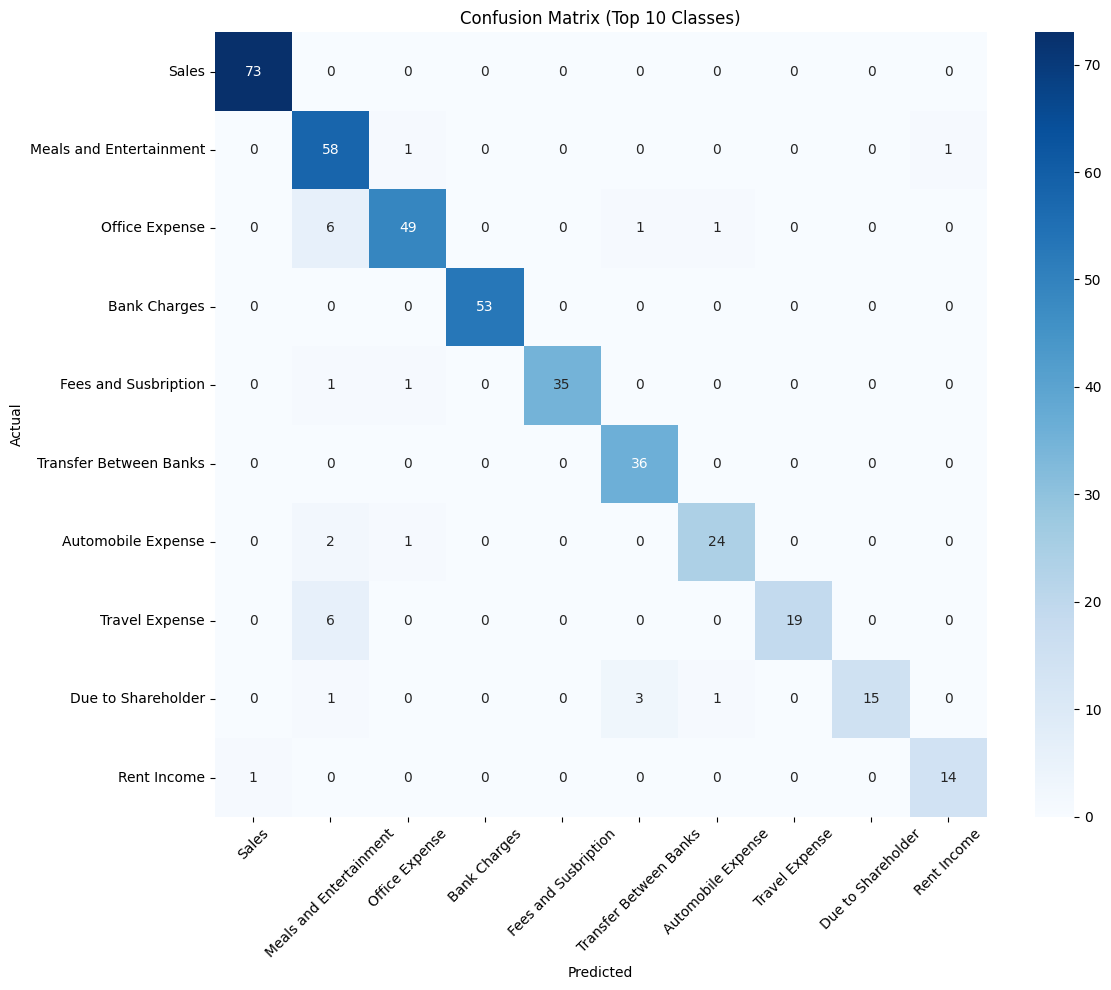

In [81]:
# Evaluate on test set (unseen data)
print("Evaluating model on test set...")

# Make predictions on test set
y_test_pred = best_rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
print("\nConfusion Matrix (Top 10 classes):")
cm = confusion_matrix(y_test, y_test_pred)
classes = best_rf_model.classes_

# Get top 10 most frequent classes for better visualization
top_classes = y_test.value_counts().head(10).index
top_class_indices = [list(classes).index(cls) for cls in top_classes if cls in classes]

if top_class_indices:
    cm_subset = cm[np.ix_(top_class_indices, top_class_indices)]
    classes_subset = [classes[i] for i in top_class_indices]
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes_subset, yticklabels=classes_subset)
    plt.title('Confusion Matrix (Top 10 Classes)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 8. Feature Importance Analysis


Analyzing feature importance...
Top 20 Most Important Features:
                    feature  importance
6                Amount_Abs    0.050734
8                Amount_Log    0.049391
7                  IsIncome    0.036250
9        Description_Length    0.034897
2                       Day    0.025454
432               tfidf_fee    0.022190
0                      Year    0.018979
10               Word_Count    0.017154
1                     Month    0.016006
3                 DayOfWeek    0.015720
11              Has_Numbers    0.012930
5                   Quarter    0.010644
941          tfidf_transfer    0.010032
12        Has_Special_Chars    0.009850
530           tfidf_interac    0.009726
329               tfidf_com    0.009706
363           tfidf_deposit    0.009058
726             tfidf_petro    0.009027
874            tfidf_square    0.008387
532  tfidf_interac transfer    0.008287


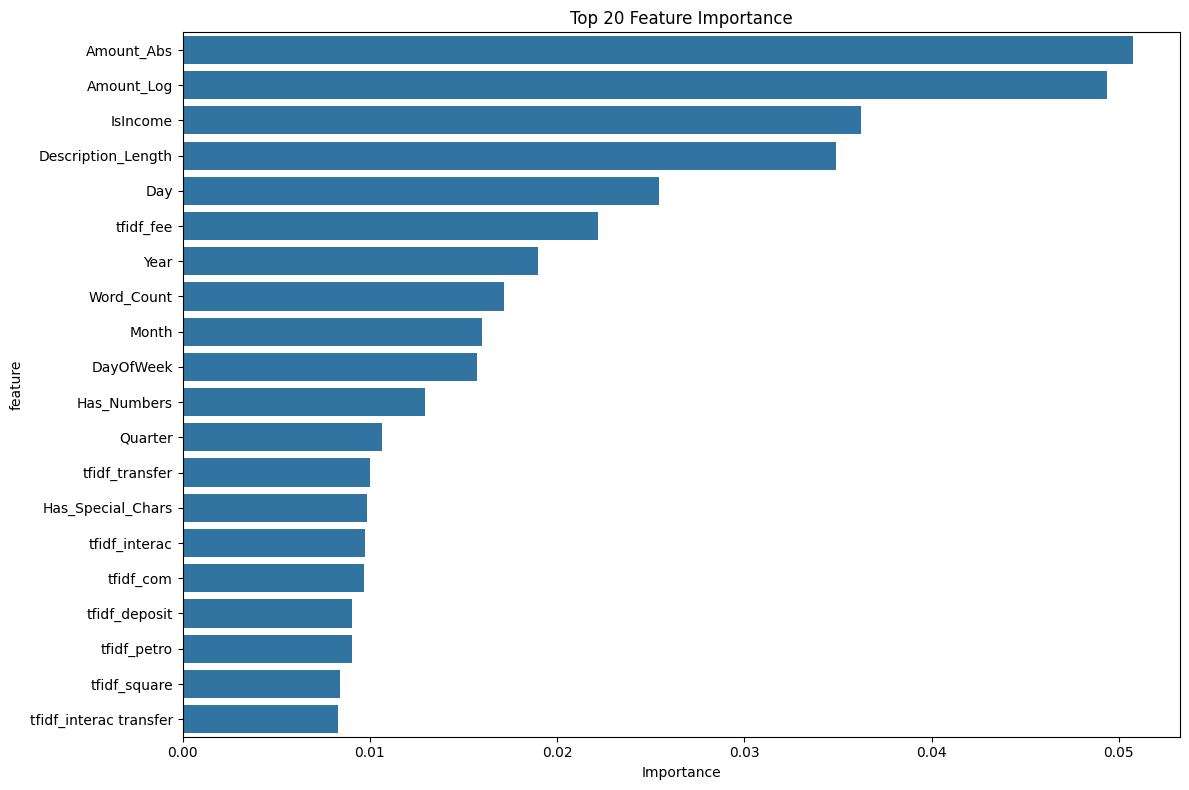


Top 10 Most Important TF-IDF Features:
                    feature  importance
432               tfidf_fee    0.022190
941          tfidf_transfer    0.010032
530           tfidf_interac    0.009726
329               tfidf_com    0.009706
363           tfidf_deposit    0.009058
726             tfidf_petro    0.009027
874            tfidf_square    0.008387
532  tfidf_interac transfer    0.008287
257            tfidf_canada    0.007705
541        tfidf_investment    0.007111

Basic Feature Importance:
               feature  importance
6           Amount_Abs    0.050734
8           Amount_Log    0.049391
7             IsIncome    0.036250
9   Description_Length    0.034897
2                  Day    0.025454
0                 Year    0.018979
10          Word_Count    0.017154
1                Month    0.016006
3            DayOfWeek    0.015720
11         Has_Numbers    0.012930
5              Quarter    0.010644
12   Has_Special_Chars    0.009850
4            IsWeekend    0.005661


In [82]:
# Analyze feature importance
print("Analyzing feature importance...")

# Get feature importance
feature_importance = best_rf_model.feature_importances_
feature_names = X_combined.columns

# Create importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(importance_df.head(20))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
sns.barplot(data=top_features, x='importance', y='feature')
plt.title('Top 20 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Analyze TF-IDF features specifically
tfidf_features = importance_df[importance_df['feature'].str.startswith('tfidf_')]
print(f"\nTop 10 Most Important TF-IDF Features:")
print(tfidf_features.head(10))

# Analyze basic features
basic_features = importance_df[~importance_df['feature'].str.startswith('tfidf_')]
print(f"\nBasic Feature Importance:")
print(basic_features)


## 9. Model Saving and Prediction Function


In [83]:
import joblib
import pickle

# Save the trained model and preprocessing objects
print("Saving improved model and preprocessing objects...")

# Create a dictionary with all necessary objects
model_package = {
    'model': rf_model,  # Use the improved model
    'tfidf_vectorizer': tfidf,
    'feature_columns': feature_columns,
    'class_names': rf_model.classes_,
    'feature_importance': importance_df
}

# Save to file
model_path = '../models/account_predictor_model_improved.pkl'
joblib.dump(model_package, model_path)

print(f"Improved model saved to: {model_path}")

# Create a prediction function
def predict_account(date, description, amount):
    """
    Predict account category for a new transaction
    
    Parameters:
    - date: Transaction date (string or datetime)
    - description: Transaction description (string)
    - amount: Transaction amount (float)
    
    Returns:
    - predicted_account: Predicted account category
    - confidence: Prediction confidence score
    """
    
    # Create a single-row DataFrame
    new_transaction = pd.DataFrame({
        'Date': [pd.to_datetime(date)],
        'Description': [description],
        'Amount': [amount]
    })
    
    # Create features (same as training)
    new_transaction['Year'] = new_transaction['Date'].dt.year
    new_transaction['Month'] = new_transaction['Date'].dt.month
    new_transaction['Day'] = new_transaction['Date'].dt.day
    new_transaction['DayOfWeek'] = new_transaction['Date'].dt.dayofweek
    new_transaction['IsWeekend'] = (new_transaction['DayOfWeek'] >= 5).astype(int)
    new_transaction['Quarter'] = new_transaction['Date'].dt.quarter
    
    new_transaction['Amount_Abs'] = new_transaction['Amount'].abs()
    new_transaction['IsIncome'] = (new_transaction['Amount'] > 0).astype(int)
    new_transaction['Amount_Log'] = np.log1p(new_transaction['Amount_Abs'])
    
    new_transaction['Description_Length'] = new_transaction['Description'].str.len()
    new_transaction['Word_Count'] = new_transaction['Description'].str.split().str.len()
    new_transaction['Has_Numbers'] = new_transaction['Description'].str.contains(r'\d').astype(int)
    new_transaction['Has_Special_Chars'] = new_transaction['Description'].str.contains(r'[!@#$%^&*(),.?":{}|<>]').astype(int)
    
    # Clean description for TF-IDF
    new_transaction['Description_Clean'] = new_transaction['Description'].apply(clean_text)
    
    # Create TF-IDF features
    tfidf_features = tfidf.transform(new_transaction['Description_Clean'])
    tfidf_df_new = pd.DataFrame(
        tfidf_features.toarray(),
        columns=[f'tfidf_{word}' for word in tfidf.get_feature_names_out()]
    )
    
    # Combine features
    X_new = pd.concat([new_transaction[feature_columns], tfidf_df_new], axis=1)
    
    # Ensure same columns as training data
    X_new = X_new.reindex(columns=X_combined.columns, fill_value=0)
    
    # Make prediction
    prediction = best_rf_model.predict(X_new)[0]
    confidence = best_rf_model.predict_proba(X_new).max()
    
    return prediction, confidence

# Test the prediction function
print("\nTesting prediction function...")
test_prediction, test_confidence = predict_account(
    '2024-01-15', 
    'Office Supplies - Staples', 
    -45.50
)
print(f"Test prediction: {test_prediction} (confidence: {test_confidence:.3f})")


Saving improved model and preprocessing objects...
Improved model saved to: ../models/account_predictor_model_improved.pkl

Testing prediction function...
Test prediction: Meals and Entertainment (confidence: 0.440)


## 10. Summary and Next Steps


In [84]:
# Final Summary
print("="*60)
print("ACCOUNT PREDICTOR MODEL - TRAINING COMPLETE")
print("="*60)

print(f"📊 Dataset: {len(df)} transactions")
print(f"🎯 Account Categories: {y.nunique()}")
print(f"🔧 Features Created: {X_combined.shape[1]}")
print(f"📈 Test Accuracy: {test_accuracy:.1%}")
print(f"💾 Model Saved: {model_path}")

print(f"\n🏆 Top 5 Most Important Features:")
for i, (_, row) in enumerate(importance_df.head(5).iterrows(), 1):
    print(f"{i}. {row['feature']}: {row['importance']:.4f}")

print(f"\n✅ Model is ready for predictions!")
print(f"Use the predict_account() function to classify new transactions.")

# Example predictions
print(f"\n🔮 Example Predictions:")
examples = [
    ("2024-01-15", "Office Supplies - Staples", -45.50),
    ("2024-01-16", "Client Payment - ABC Corp", 2500.00),
    ("2024-01-17", "Electricity Bill - ConEd", -120.75),
    ("2024-01-18", "Software Subscription - Adobe", -29.99),
    ("2024-01-19", "Business Lunch - Restaurant", -85.00)
]

for date, desc, amount in examples:
    pred, conf = predict_account(date, desc, amount)
    print(f"  {desc} (${amount}) → {pred} ({conf:.1%} confidence)")

print(f"\n🚀 Next Steps:")
print(f"1. Test the model with more of your data")
print(f"2. Add more transactions to improve accuracy")
print(f"3. Fine-tune account categories if needed")
print(f"4. Deploy the model for daily use")
print("="*60)


ACCOUNT PREDICTOR MODEL - TRAINING COMPLETE
📊 Dataset: 3301 transactions
🎯 Account Categories: 22
🔧 Features Created: 1013
📈 Test Accuracy: 92.7%
💾 Model Saved: ../models/account_predictor_model_improved.pkl

🏆 Top 5 Most Important Features:
1. Amount_Abs: 0.0507
2. Amount_Log: 0.0494
3. IsIncome: 0.0363
4. Description_Length: 0.0349
5. Day: 0.0255

✅ Model is ready for predictions!
Use the predict_account() function to classify new transactions.

🔮 Example Predictions:
  Office Supplies - Staples ($-45.5) → Meals and Entertainment (44.0% confidence)
  Client Payment - ABC Corp ($2500.0) → Sales (44.0% confidence)
  Electricity Bill - ConEd ($-120.75) → Office Expense (34.0% confidence)
  Software Subscription - Adobe ($-29.99) → Meals and Entertainment (53.0% confidence)
  Business Lunch - Restaurant ($-85.0) → Office Expense (38.0% confidence)

🚀 Next Steps:
1. Test the model with more of your data
2. Add more transactions to improve accuracy
3. Fine-tune account categories if needed

In [85]:
# Test the improved model with sample predictions
print("Testing model with sample predictions...")

def predict_single_transaction(date, description, amount):
    """Predict account for a single transaction"""
    # Create features for new transaction
    new_transaction = pd.DataFrame({
        'Date': [pd.to_datetime(date)],
        'Description': [description],
        'Amount': [amount]
    })
    
    # Date features
    new_transaction['Year'] = new_transaction['Date'].dt.year
    new_transaction['Month'] = new_transaction['Date'].dt.month
    new_transaction['Day'] = new_transaction['Date'].dt.day
    new_transaction['DayOfWeek'] = new_transaction['Date'].dt.dayofweek
    new_transaction['IsWeekend'] = (new_transaction['DayOfWeek'] >= 5).astype(int)
    new_transaction['Quarter'] = new_transaction['Date'].dt.quarter
    
    # Amount features
    new_transaction['Amount_Abs'] = new_transaction['Amount'].abs()
    new_transaction['IsIncome'] = (new_transaction['Amount'] > 0).astype(int)
    new_transaction['Amount_Log'] = np.log1p(new_transaction['Amount_Abs'])
    
    # Description features
    new_transaction['Description_Length'] = new_transaction['Description'].str.len()
    new_transaction['Word_Count'] = new_transaction['Description'].str.split().str.len()
    new_transaction['Has_Numbers'] = new_transaction['Description'].str.contains(r'\d').astype(int)
    new_transaction['Has_Special_Chars'] = new_transaction['Description'].str.contains(r'[!@#$%^&*(),.?":{}|<>]').astype(int)
    
    # Clean description
    new_transaction['Description_Clean'] = new_transaction['Description'].apply(clean_text)
    
    # TF-IDF features
    tfidf_features = tfidf.transform(new_transaction['Description_Clean'])
    tfidf_df_new = pd.DataFrame(
        tfidf_features.toarray(),
        columns=[f'tfidf_{word}' for word in tfidf.get_feature_names_out()]
    )
    
    # Combine features
    X_new = pd.concat([new_transaction[feature_columns], tfidf_df_new], axis=1)
    X_new = X_new.reindex(columns=X_combined.columns, fill_value=0)
    
    # Predict
    prediction = rf_model.predict(X_new)[0]
    confidence = rf_model.predict_proba(X_new).max()
    probabilities = rf_model.predict_proba(X_new)[0]
    prob_dict = dict(zip(rf_model.classes_, probabilities))
    
    return prediction, confidence, prob_dict

# Test cases
test_cases = [
    ("2024-01-15", "Office Supplies - Staples", -45.50, "Office Expense"),
    ("2024-01-16", "COSTCO WHOLESALE", -400.99, "Office Expense"),
    ("2024-01-17", "Client Payment - ABC Corp", 2500.00, "Sales"),
    ("2024-01-18", "STARBUCKS COFFEE", -7.42, "Meals and Entertainment"),
    ("2024-01-19", "Electricity Bill - ConEd", -120.75, "Office Expense"),
    ("2024-01-20", "PRE-AUTH PYMT - OTFS FEE BPY", -40.00, "Bank Charges")
]

print("Sample Predictions:")
print("="*80)
correct = 0
total = len(test_cases)

for date, desc, amount, expected in test_cases:
    prediction, confidence, probabilities = predict_single_transaction(date, desc, amount)
    top_3 = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)[:3]
    
    is_correct = prediction == expected
    if is_correct:
        correct += 1
    
    status = "✅" if is_correct else "❌"
    print(f"{status} {desc} (${amount})")
    print(f"   Expected: {expected}")
    print(f"   Predicted: {prediction} ({confidence:.1%})")
    print(f"   Top 3: {', '.join([f'{acc}: {prob:.1%}' for acc, prob in top_3])}")
    print()

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.1%} ({correct}/{total})")

if accuracy >= 0.7:
    print("🎉 Model is performing well!")
elif accuracy >= 0.5:
    print("⚠️  Model needs improvement")
else:
    print("❌ Model needs significant improvement")


Testing model with sample predictions...
Sample Predictions:
❌ Office Supplies - Staples ($-45.5)
   Expected: Office Expense
   Predicted: Meals and Entertainment (16.4%)
   Top 3: Meals and Entertainment: 16.4%, Office Expense: 13.8%, Bank Charges: 8.0%

❌ COSTCO WHOLESALE ($-400.99)
   Expected: Office Expense
   Predicted: Meals and Entertainment (15.3%)
   Top 3: Meals and Entertainment: 15.3%, Office Expense: 13.7%, Sales: 10.5%

✅ Client Payment - ABC Corp ($2500.0)
   Expected: Sales
   Predicted: Sales (21.9%)
   Top 3: Sales: 21.9%, Transfer Between Banks: 21.5%, Office Expense: 7.8%

❌ STARBUCKS COFFEE ($-7.42)
   Expected: Meals and Entertainment
   Predicted: Bank Charges (22.4%)
   Top 3: Bank Charges: 22.4%, Meals and Entertainment: 18.3%, Office Expense: 11.9%

❌ Electricity Bill - ConEd ($-120.75)
   Expected: Office Expense
   Predicted: Meals and Entertainment (17.4%)
   Top 3: Meals and Entertainment: 17.4%, Office Expense: 14.7%, Bank Charges: 7.8%

✅ PRE-AUTH PYMT